<a href="https://colab.research.google.com/github/Tulin206/erumhub_deep-learning_2026/blob/main/code/FCNN/04_Wine_Classification_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# STEP 1: LOAD THE WINE DATASET
# ============================================================================
from sklearn.datasets import load_wine

# Load the dataset into a variable
# The load_wine() function returns a 'Bunch' object (like a dictionary)
dataset = load_wine()

# The 'dataset' contains 4 important keys:
#   dataset['data']           --> 2D array of shape (178, 13)
#                                 178 wine samples, 13 features each
#   dataset['target']         --> 1D array of shape (178,)
#                                 Class labels: 0, 1, or 2 (wine class)
#   dataset['feature_names']  --> Tuple of 13 feature names
#                                 Names like 'Alcohol', 'Malic acid', etc.
#   dataset['target_names']   --> Tuple of 3 class names
#                                 Names of the 3 wine classes

# Display (uncomment to see):
# dataset

# Print the shape of the dataset
print("\n" + "="*80)
print("DATASET SHAPE")
print("="*80)
print(f"dataset['data'].shape: {dataset['data'].shape}")
print(f"  Meaning: 178 wine samples with 13 features each")
print(f"\ndataset['target'].shape: {dataset['target'].shape}")
print(f"  Meaning: 178 class labels (one for each wine sample)")


DATASET SHAPE
dataset['data'].shape: (178, 13)
  Meaning: 178 wine samples with 13 features each

dataset['target'].shape: (178,)
  Meaning: 178 class labels (one for each wine sample)


In [ ]:
# ============================================================================
# STEP 2: EXPLORE THE DATASET STRUCTURE
# ============================================================================
# Import pandas for data manipulation
import pandas as pd

# WHAT IS dataset['feature_names']?
# Answer: A list/tuple of the 13 column names (characteristics) measured for each wine
print("="*80)
print("What is dataset['feature_names']?")
print("="*80)
print("It contains the names of all 13 features (input columns):")
print(dataset['feature_names'])


What is dataset['feature_names']?
It contains the names of all 13 features (input columns):
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [ ]:
# CREATE DATAFRAMES TO VISUALIZE THE DATA
# We'll use dataset['data'] and dataset['feature_names'] together to create a table
# df_features = DataFrame(data_values, column_names)

print("\n" + "="*80)
print("UNDERSTANDING THE DATASET WITH ROWS AND COLUMNS")
print("="*80)

# Create DataFrame from dataset['data'] with feature names as column headers
# dataset['data'] --> 2D array (178 rows × 13 columns)
# dataset['feature_names'] --> column names from the dataset dictionary
df_features = pd.DataFrame(dataset['data'], columns=dataset['feature_names'])

# Create DataFrame from dataset['target'] (the output labels)
# dataset['target'] --> 1D array of 178 class labels
df_target = pd.DataFrame(dataset['target'], columns=['Wine_Class'])

print("\n--- DATASET OVERVIEW ---")
print(f"Total number of wine samples (ROWS): {df_features.shape[0]}")
print(f"Total number of features/columns: {df_features.shape[1]}")
print(f"Number of wine classes from dataset['target_names']: {len(dataset['target_names'])}")
print(f"Wine classes: {dataset['target_names']}")



UNDERSTANDING THE DATASET WITH ROWS AND COLUMNS

--- DATASET OVERVIEW ---
Total number of wine samples (ROWS): 178
Total number of features/columns: 13
Number of wine classes from dataset['target_names']: 3
Wine classes: ['class_0' 'class_1' 'class_2']


In [ ]:
# Display the first few rows of FEATURES (X)
print("\nFEATURES (First 5 rows) - These are the input variables (what we give to the model):")
print(df_features.head())


FEATURES (First 5 rows) - These are the input variables (what we give to the model):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82    

In [ ]:
# Display the first few rows of TARGET (y)
print("\nTARGET (First 5 rows) - This is the output variable (what we want to predict):")
print(f"Target values (class labels): {df_target.head().values.flatten()}")
print(f"\nTarget mapping from dataset['target_names']:")
for i, class_name in enumerate(dataset['target_names']):
    print(f"  Class {i}: {class_name}")


TARGET (First 5 rows) - This is the output variable (what we want to predict):
Target values (class labels): [0 0 0 0 0]

Target mapping from dataset['target_names']:
  Class 0: class_0
  Class 1: class_1
  Class 2: class_2


In [ ]:
# ============================================================================
# STEP 3: PREPARE DATA FOR THE NEURAL NETWORK
# ============================================================================
# Assign the feature data to X and one-hot encode the target labels
# X = dataset['data']  --> Features (input to model)
# y = pd.get_dummies(dataset["target"])  --> Target (one-hot encoded output)
y = pd.get_dummies(dataset["target"])
X = dataset['data']

In [ ]:
# Show the BEFORE one-hot encoding (original target labels)
print("="*80)
print("ONE-HOT ENCODING EXPLANATION")
print("="*80)

print("\nBEFORE one-hot encoding (showing samples from all 3 classes):")
print("Remember: Dataset is organized as Class 0 (0-58), Class 1 (59-130), Class 2 (131-177)")
print("\nSample indices: [0, 1, 59, 60, 131, 132]  (samples from each class)")
sample_indices = [0, 1, 59, 60, 131, 132]
print("Values:", dataset["target"][sample_indices])

print("\n" + "="*80)
print("AFTER one-hot encoding (same samples):")
print("="*80)
print(y.iloc[sample_indices])

print("\n" + "="*80)
print("WHY ONE-HOT ENCODE?")
print("="*80)
print("Neural networks need binary format where each class becomes a binary column:")
print("  Class 0 --> [1, 0, 0]  (column 0=1, columns 1,2=0)")
print("  Class 1 --> [0, 1, 0]  (column 1=1, columns 0,2=0)")
print("  Class 2 --> [0, 0, 1]  (column 2=1, columns 0,1=0)")

ONE-HOT ENCODING EXPLANATION

BEFORE one-hot encoding (showing samples from all 3 classes):
Remember: Dataset is organized as Class 0 (0-58), Class 1 (59-130), Class 2 (131-177)

Sample indices: [0, 1, 59, 60, 131, 132]  (samples from each class)
Values: [0 0 1 1 2 2]

AFTER one-hot encoding (same samples):
         0      1      2
0     True  False  False
1     True  False  False
59   False   True  False
60   False   True  False
131  False  False   True
132  False  False   True

WHY ONE-HOT ENCODE?
Neural networks need binary format where each class becomes a binary column:
  Class 0 --> [1, 0, 0]  (column 0=1, columns 1,2=0)
  Class 1 --> [0, 1, 0]  (column 1=1, columns 0,2=0)
  Class 2 --> [0, 0, 1]  (column 2=1, columns 0,1=0)


In [ ]:
# Import StandardScaler for feature normalization
from sklearn.preprocessing import StandardScaler
# Fit the scaler to X and transform X to have zero mean and unit variance
scaler = StandardScaler().fit(X)
X_ = scaler.transform(X)

In [ ]:
# Print the mean values per column after scaling
print("mean values per column:\n", X_.mean(axis=-2))

mean values per column:
 [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17 -1.95536471e-16  9.44313292e-16 -4.17892936e-16
 -1.54059038e-15 -4.12903170e-16  1.39838203e-15  2.12688793e-15
 -6.98567296e-17]


In [ ]:
# Print the standard deviation values per column after scaling
print("std  values per column:\n", X_.std(axis=-2))

std  values per column:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# Import train_test_split to split data into training and test sets
from sklearn.model_selection import train_test_split

# Split the data into training and test sets, stratified by the target labels
X_train, X_test, y_train, y_test = train_test_split(X_, y ,test_size=0.2,
                                                    random_state=0,
                                                    shuffle=True,
                                                    stratify=y)


In [ ]:
# Print the shapes of the train and test splits for features and targets
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(142, 13) (36, 13) (142, 3) (36, 3)


In [ ]:
# Set random seeds for reproducibility
from numpy.random import seed
seed(1)
from tensorflow.random import set_seed
set_seed(2)
from tensorflow import keras



In [ ]:
def create_model(X_shape):
    # Input layer
    inputs = keras.Input(shape=(X_shape[1],))
    # Hidden layer with 16 units and ReLU activation
    hidden_layer = keras.layers.Dense(16, activation="relu")(inputs)
    # Output layer with 3 units (for 3 classes) and softmax activation
    output_layer = keras.layers.Dense(3, activation="softmax")(hidden_layer)
    # Create the model object
    model = keras.Model(inputs=inputs, outputs=output_layer)
    return model

In [ ]:
# Create the model using the training data shape
model = create_model(X_train.shape)

In [ ]:
# Display the model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.07 KB)

 Trainable params: 275 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model with Adam optimizer and categorical crossentropy loss
model.compile(optimizer='adam', loss=keras.losses.CategoricalCrossentropy())

In [ ]:
# Train the model on the training data for 18 epochs
history = model.fit(X_train, y_train, epochs=18)

Epoch 1/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0854
Epoch 2/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0065 
Epoch 3/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9341 
Epoch 4/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8664 
Epoch 5/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8036 
Epoch 6/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7455 
Epoch 7/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6919 
Epoch 8/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6430 
Epoch 9/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5985 
Epoch 10/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5578 
Epoch 11/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5206 
Epoch 12/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4866 
Epoch 13/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4555 
Epoch 14/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4270 
Epoch 15/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4008 
Epoch 16/18
5/5 ━━━━━━━━━━━━━━━━━━━

<Axes: >

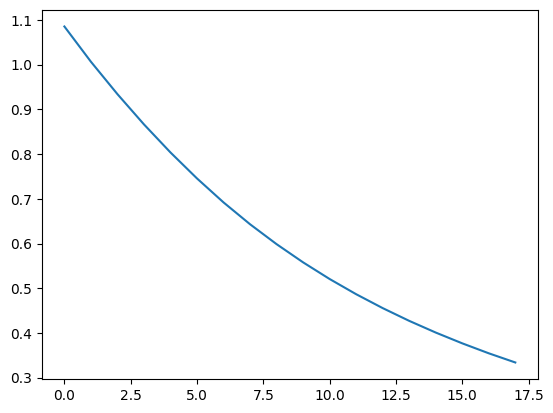

In [ ]:
# Import seaborn for plotting
import seaborn as sns
# Plot the training loss over epochs
sns.lineplot(x=history.epoch, y=history.history['loss'])

============================================================================
## STEP 4: MAKE PREDICTIONS AND EVALUATE THE MODEL
============================================================================

### Understanding Predictions - What Does the Neural Network Output?

When we use `model.predict(X_test)`, the neural network outputs **probability scores** for each wine class.

#### What Are These Probabilities?

- The model looks at each test wine sample (13 features)
- For each sample, it calculates: "What's the probability this wine belongs to Class 0, Class 1, or Class 2?"
- These probabilities always sum to 1.0 (they must add up to 100%)

#### The Prediction DataFrame:

The table we're about to see has:
- **Rows** = individual test wine samples (36 total)
- **Column 0** = probability the wine is Class 0
- **Column 1** = probability the wine is Class 1
- **Column 2** = probability the wine is Class 2

#### Example Output:
```
         0         1         2
0  0.98453  0.01234  0.00313
1  0.02145  0.96789  0.01066
2  0.12340  0.05678  0.81982
```

**Row 0 means:**
- 98.45% chance it's Class 0
- 1.23% chance it's Class 1
- 0.31% chance it's Class 2
→ **Most likely Class 0** ✓

**Row 1 means:**
- 2.15% chance it's Class 0
- 96.79% chance it's Class 1 ← **HIGHEST**
- 1.07% chance it's Class 2
→ **Most likely Class 1** ✓

---


In [ ]:
# Make predictions on the test data
y_pred = model.predict(X_test)
# Create a DataFrame for the predictions
prediction = pd.DataFrame(y_pred, columns=y.columns)
# Display the predictions
print("="*80)
print("PREDICTION PROBABILITIES FOR EACH TEST SAMPLE")
print("="*80)
print("Each row = one wine sample")
print("Each column = probability of belonging to that class")
print("Values should sum to ~1.0 across each row")
print("="*80)
prediction

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


,0,1,2
0,0.010581,0.913578,0.075841
1,0.196799,0.151573,0.651627
2,0.004458,0.803857,0.191685
3,0.478072,0.148330,0.373599
4,0.012294,0.960975,0.026731
5,0.683788,0.099641,0.216572
6,0.826794,0.061239,0.111967
7,0.213158,0.194293,0.592549
8,0.013328,0.902138,0.084534
9,0.337995,0.197421,0.464585


============================================================================
## CONVERTING PROBABILITIES TO FINAL PREDICTIONS
============================================================================

### From Probabilities to Class Labels

Above, we saw probabilities for each class. But which class does the model **actually predict**?

#### The Solution: `idxmax()` - "Index of Maximum"

The `.idxmax(axis="columns")` function does something simple:
**For each row (wine sample), find which column has the highest probability.**

#### Example:

If the prediction DataFrame showed:
```
         0         1         2
0  0.98453  0.01234  0.00313   ← Max is 0.98453 in column 0 → Predict Class 0
1  0.02145  0.96789  0.01066   ← Max is 0.96789 in column 1 → Predict Class 1
2  0.12340  0.05678  0.81982   ← Max is 0.81982 in column 2 → Predict Class 2
```

Then `predicted_species` would show: `[0, 1, 2, ...]`

#### Why This Makes Sense:

The neural network outputs probabilities because it's **uncertain**.
- If probability = [0.95, 0.04, 0.01] → Very confident it's Class 0 ✓
- If probability = [0.34, 0.33, 0.33] → Very uncertain, almost a guess ⚠️

By picking the highest probability, we make the **best guess** the model can make.

---


In [ ]:
# Get the predicted species by finding the class with the highest probability
predicted_species = prediction.idxmax(axis="columns")
print("="*80)
print("FINAL PREDICTED CLASS FOR EACH TEST SAMPLE")
print("="*80)
print("(Showing which class the model predicts for each wine)")
print("="*80)
predicted_species

,0
0,1
1,2
2,1
3,0
4,1
5,0
6,0
7,2
8,1
9,2


============================================================================
## UNDERSTANDING THE CONFUSION MATRIX - EXPLAINED FOR BEGINNERS
============================================================================

### What is a Confusion Matrix?

A **confusion matrix** is a table that shows how well your model performed on the test data.

- **Rows** = True class (what the wine actually is)
- **Columns** = Predicted class (what the model predicted)
- **Each cell** = Number of samples in that combination

### How to Read It:

For a 3-class problem (Classes 0, 1, 2):

```
       Predicted 0  Predicted 1  Predicted 2
True 0     [ ]          [ ]          [ ]
True 1     [ ]          [ ]          [ ]
True 2     [ ]          [ ]          [ ]
```

**Diagonal values (top-left to bottom-right)** = CORRECT predictions
- If True 0 is predicted as 0, that's correct ✓

**Off-diagonal values** = INCORRECT predictions (misclassifications)
- If True 0 is predicted as 1, that's wrong ✗

## Example:
```
[[30,  1,  0],
 [ 0, 25,  3],
 [ 0,  2, 10]]
```

This means:
- 30 True Class 0 wines were correctly predicted as Class 0 ✓
- 1 True Class 0 wine was incorrectly predicted as Class 1 ✗
- 25 True Class 1 wines were correctly predicted as Class 1 ✓
- 3 True Class 1 wines were incorrectly predicted as Class 2 ✗
- And so on...

---


In [ ]:
# Import confusion_matrix and accuracy_score for model evaluation
from sklearn.metrics import confusion_matrix, accuracy_score

# Get the true species from the test set
true_species = y_test.idxmax(axis="columns")

# Compute the confusion matrix
matrix = confusion_matrix(true_species, predicted_species)
# Display the confusion matrix
print(matrix)

[[12  0  0]
 [ 1 13  0]
 [ 1  3  6]]


============================================================================
## UNDERSTANDING ACCURACY SCORE - EXPLAINED FOR BEGINNERS
============================================================================

### What is Accuracy?

**Accuracy** is a simple metric that tells you what percentage of your predictions were correct.

#### Formula:
```
Accuracy = (Number of Correct Predictions) / (Total Number of Predictions)
```

#### Example:
If you made 36 predictions and got 34 correct:
```
Accuracy = 34 / 36 = 0.9444 (or 94.44%)
```

### What Does Each Accuracy Value Mean?

- **Accuracy = 1.0 (or 100%)** → Perfect! All predictions were correct ✓
- **Accuracy = 0.9 (or 90%)** → Very good! 90 out of 100 predictions were correct
- **Accuracy = 0.7 (or 70%)** → Fair. 70 out of 100 predictions were correct
- **Accuracy = 0.5 (or 50%)** → Not great. Only half the predictions were correct
- **Accuracy = 0.33 (or 33%)** → Poor (for 3 classes, random guessing would give ~33%)

### How it Relates to the Confusion Matrix:

The accuracy is calculated by:
1. Counting the **diagonal values** in the confusion matrix (correct predictions)
2. Dividing by the **total number of test samples**

So if the confusion matrix had 34 correct predictions out of 36 total test samples, accuracy = 0.9444.

---


In [ ]:
# Calculate and print the accuracy of the model
accuracy_score(true_species, predicted_species)

0.8611111111111112